# Import Libraries and Images


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score,confusion_matrix



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

root_path = "/content/drive/MyDrive"
print(os.listdir(root_path))


['Colab Notebooks', 'Untitled form.gform', 'Accident_Information.csv', 'covid_dataset', 'Covid vs Normal.zip', 'Covid-Normal', 'archive (79).zip', 'instacart_data', 'covid_big_zip.zip', 'covid_big', 'covid_split_datasets', 'covid_big_2.zip', 'covid_big_2']


In [4]:
base_dir = "/content/drive/MyDrive/covid_dataset"

print(os.listdir(base_dir))


['New_covid_vs_normal']


In [5]:
print("Contents of Covid_New:", os.listdir(base_dir + "/New_covid_vs_normal/Covid_New"))
print("Contents of Normal_New:", os.listdir(base_dir + "/New_covid_vs_normal/Normal_New"))

Contents of Covid_New: ['Mask', 'Covid']
Contents of Normal_New: ['Normal_mask', 'Normal']


In [6]:
import os

base_dir = "/content/drive/MyDrive/covid_dataset/New_covid_vs_normal"

covid_img_dir  = os.path.join(base_dir, "Covid_New", "Covid")
covid_mask_dir = os.path.join(base_dir, "Covid_New", "Mask")

normal_img_dir  = os.path.join(base_dir, "Normal_New", "Normal")
normal_mask_dir = os.path.join(base_dir, "Normal_New", "Normal_mask")

print("COVID images count:", len(os.listdir(covid_img_dir)))
print("COVID masks count:", len(os.listdir(covid_mask_dir)))
print("NORMAL images count:", len(os.listdir(normal_img_dir)))
print("NORMAL masks count:", len(os.listdir(normal_mask_dir)))


COVID images count: 500
COVID masks count: 500
NORMAL images count: 500
NORMAL masks count: 500


In [7]:
classes = ['Covid' , 'Normal']
counts = []

# Create a mapping from class name to its corresponding image directory
class_dirs = {
    'Covid': covid_img_dir,
    'Normal': normal_img_dir
}

for cls in classes:
    # Use the correct, pre-defined directory for each class
    folder = class_dirs[cls]
    num_images = len([file for file in os.listdir(folder) if file.lower().endswith(('.png', '.jpg', '.jpeg'))])
    counts.append(num_images)
    print(f"{cls}: {num_images} images")

Covid: 500 images
Normal: 500 images


***Class distribution***

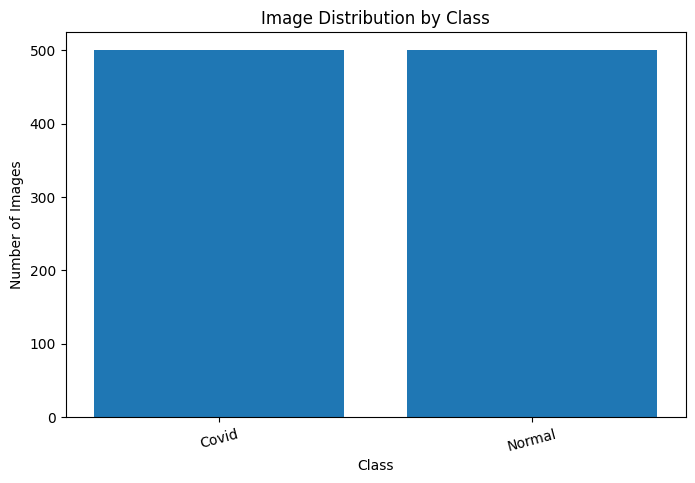

In [8]:
plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.title("Image Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.show()

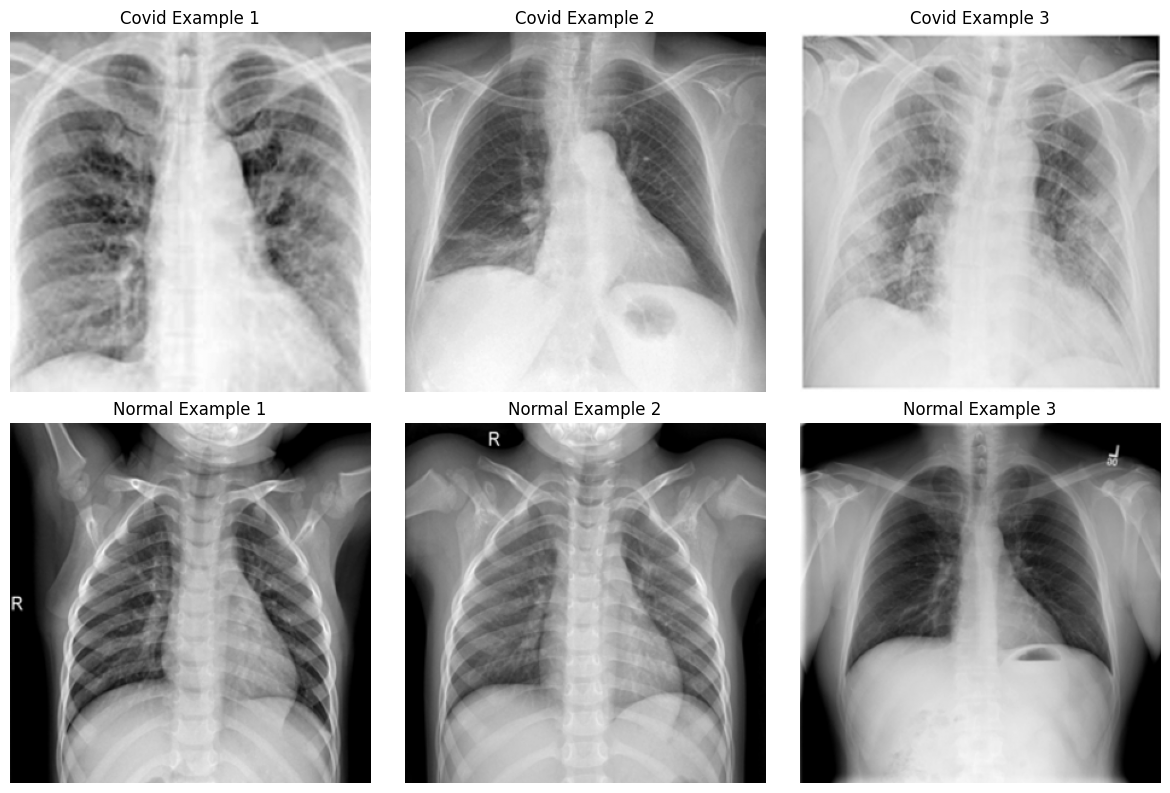

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

num_examples = 3

covid_image_files = os.listdir(covid_img_dir)
random.shuffle(covid_image_files)
covid_example_paths = [os.path.join(covid_img_dir, f) for f in covid_image_files[:num_examples]]

normal_image_files = os.listdir(normal_img_dir)
random.shuffle(normal_image_files)
normal_example_paths = [os.path.join(normal_img_dir, f) for f in normal_image_files[:num_examples]]

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(covid_example_paths):
    plt.subplot(2, num_examples, i + 1)
    img = Image.open(img_path)
    plt.imshow(img,cmap='gray')
    plt.title(f'Covid Example {i+1}')
    plt.axis('off')


for i, img_path in enumerate(normal_example_paths):
    plt.subplot(2, num_examples, num_examples + i + 1)
    img = Image.open(img_path)
    plt.imshow(img, cmap='gray')
    plt.title(f'Normal Example {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


**A random sample of X-ray images was visually inspected. The images show light grainy noise without directional blur. This indicates that the dominant noise in the dataset is Gaussian noise.**

# Preprocessing

In [10]:
import os
import shutil
from sklearn.model_selection import train_test_split


split_data_dir = './split_data'


train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1


os.makedirs(split_data_dir, exist_ok=True)


splits = ['train', 'validation', 'test']
classes = ['Covid', 'Normal']

for split in splits:
    for cls in classes:
        path = os.path.join(split_data_dir, split, cls)
        os.makedirs(path, exist_ok=True)
        print(f"Created directory: {path}")


Created directory: ./split_data/train/Covid
Created directory: ./split_data/train/Normal
Created directory: ./split_data/validation/Covid
Created directory: ./split_data/validation/Normal
Created directory: ./split_data/test/Covid
Created directory: ./split_data/test/Normal


In [11]:
# Get list of all Covid and Normal image files from original directories
covid_files = [os.path.join(covid_img_dir, f) for f in os.listdir(covid_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
normal_files = [os.path.join(normal_img_dir, f) for f in os.listdir(normal_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]


covid_train_val, covid_test = train_test_split(covid_files, test_size=test_ratio, random_state=42)
covid_train, covid_val = train_test_split(covid_train_val, test_size=val_ratio/(train_ratio + val_ratio), random_state=42)


normal_train_val, normal_test = train_test_split(normal_files, test_size=test_ratio, random_state=42)
normal_train, normal_val = train_test_split(normal_train_val, test_size=val_ratio/(train_ratio + val_ratio), random_state=42)

print(f"Covid Train: {len(covid_train)} | Val: {len(covid_val)} | Test: {len(covid_test)}")
print(f"Normal Train: {len(normal_train)} | Val: {len(normal_val)} | Test: {len(normal_test)}")


Covid Train: 349 | Val: 101 | Test: 50
Normal Train: 349 | Val: 101 | Test: 50


In [12]:

def copy_files(file_list, destination_dir):
    for file_path in file_list:
        shutil.copy(file_path, destination_dir)


copy_files(covid_train, os.path.join(split_data_dir, 'train', 'Covid'))
copy_files(covid_val, os.path.join(split_data_dir, 'validation', 'Covid'))
copy_files(covid_test, os.path.join(split_data_dir, 'test', 'Covid'))


copy_files(normal_train, os.path.join(split_data_dir, 'train', 'Normal'))
copy_files(normal_val, os.path.join(split_data_dir, 'validation', 'Normal'))
copy_files(normal_test, os.path.join(split_data_dir, 'test', 'Normal'))

print("All images copied to their respective split directories.")


All images copied to their respective split directories.


In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2 ,
    horizontal_flip=False
)

validation_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    './split_data/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

valid_generator = validation_datagen.flow_from_directory(
    './split_data/validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    './split_data/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 698 images belonging to 2 classes.
Found 202 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


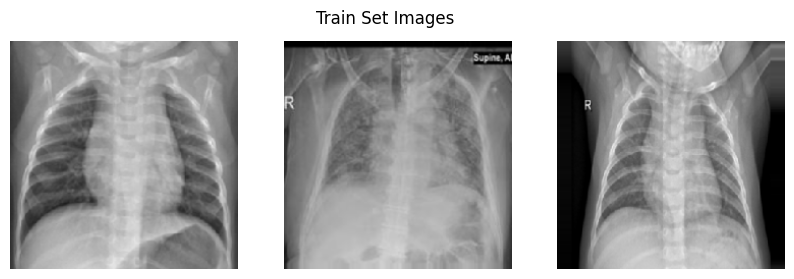

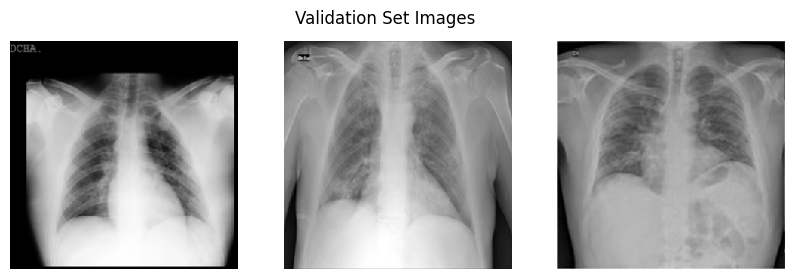

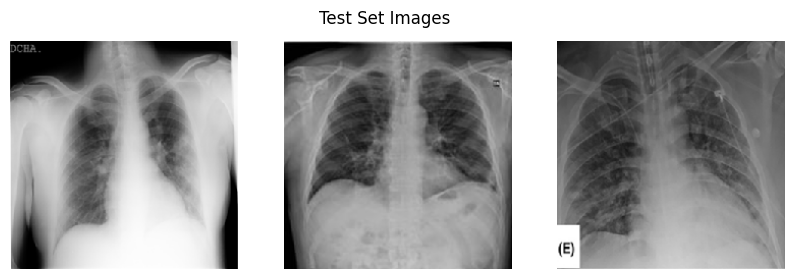

In [14]:
# prompt: print 3 images from every folder in train_generator, validation, test , every three images in one row

import matplotlib.pyplot as plt

def plot_images(generator, title):
  """Plots 3 images from a generator in a row."""
  x, y = next(generator)
  fig, axes = plt.subplots(1, 3, figsize=(10, 3))
  fig.suptitle(title, fontsize=12)
  for i in range(3):
    axes[i].imshow(x[i])
    axes[i].axis('off')
  plt.show()

plot_images(train_generator, "Train Set Images")
plot_images(valid_generator, "Validation Set Images")
plot_images(test_generator, "Test Set Images")


# Model 1

In [15]:
img_size = 224

model1 = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model_checkpoint_callback1 = tf.keras.callbacks.ModelCheckpoint(
    filepath="CNN.weights.h5",
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

model1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model1.fit(
    train_generator,
    epochs=2,
    validation_data=valid_generator,
    callbacks=[model_checkpoint_callback1]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.5528 - loss: 1.1175 - val_accuracy: 0.9109 - val_loss: 0.2842
Epoch 2/2
22/22 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.8882 - loss: 0.3291 - val_accuracy: 0.9208 - val_loss: 0.2713


**LOSS  & VAL_LOSS**

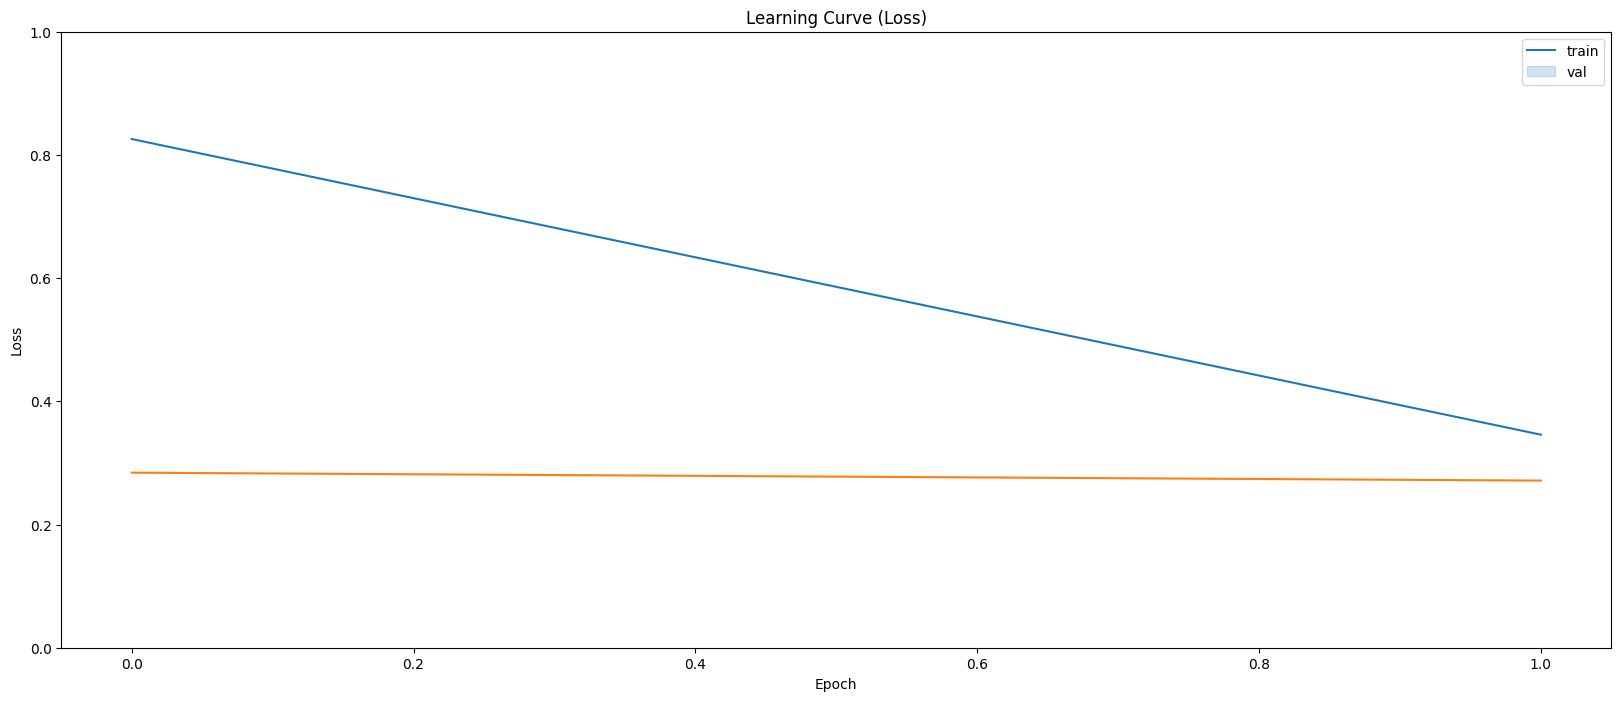

In [17]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 1)
ax.legend(['train', 'val'], loc='best')
plt.show()

**ACCURACY VS VAL_ACCURACY**

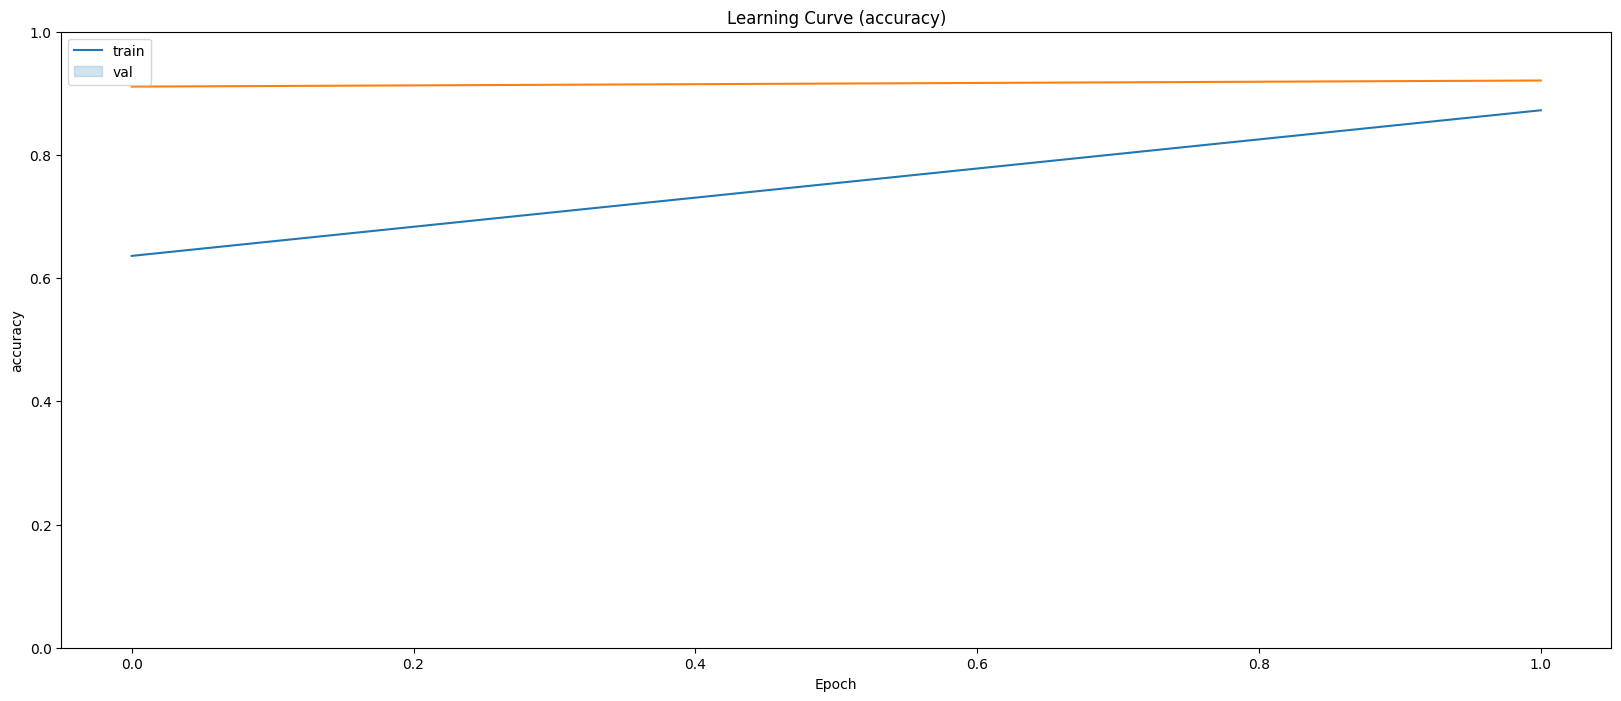

In [18]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_accuracy'])
ax.set_title('Learning Curve (accuracy)')
ax.set_ylabel('accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 1)
ax.legend(['train', 'val'], loc='best')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 591ms/step


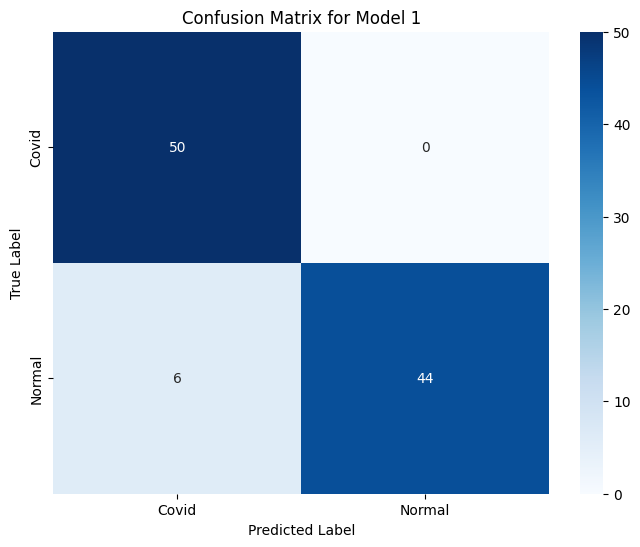

In [20]:
model1.load_weights('CNN.weights.h5')

test_labels = test_generator.classes

predictions = model1.predict(test_generator)

y_pred = np.round(predictions).flatten()

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix for Model 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [36]:
score = model1.evaluate(test_generator, verbose = 0)

print('Test loss:', score[0])
print('Test accuracy:', round(score[1],2))

Test loss: 0.2544550597667694
Test accuracy: 0.94


**The learning curve shows that both training loss and validation loss decrease steadily over the epochs. This indicates that the model is learning effectively. The validation loss remains lower than the training loss, which suggests good generalization and no signs of overfitting. Overall, the model performance is improving in a stable and right way.**

**The loss curves decrease smoothly for both training and validation, showing stable learning without clear overfitting, but the model is used mainly as a baseline.**

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

# Model 2

In [24]:
from matplotlib.cbook import flatten
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout

model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    layers.Flatten(),

    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=2)
checkpoint2 = callbacks.ModelCheckpoint('best_model2.keras', monitor='val_loss', save_best_only=True)
reduce_lr2 = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=2, min_lr=0.001)
model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [26]:
history2 = model2.fit(
    train_generator,
    epochs=7,
    validation_data=valid_generator,
    callbacks = [early_stop, checkpoint2, reduce_lr2])

Epoch 1/7
22/22 ━━━━━━━━━━━━━━━━━━━━ 107s 5s/step - accuracy: 0.5827 - loss: 0.6788 - val_accuracy: 0.6139 - val_loss: 0.5630 - learning_rate: 0.0010
Epoch 2/7
22/22 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.8062 - loss: 0.4577 - val_accuracy: 0.9158 - val_loss: 0.3074 - learning_rate: 0.0010
Epoch 3/7
22/22 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.8594 - loss: 0.3631 - val_accuracy: 0.8861 - val_loss: 0.2793 - learning_rate: 0.0010
Epoch 4/7
22/22 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.8997 - loss: 0.2972 - val_accuracy: 0.9307 - val_loss: 0.2125 - learning_rate: 0.0010
Epoch 5/7
22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9266 - loss: 0.2288 - val_accuracy: 0.9257 - val_loss: 0.2126 - learning_rate: 0.0010
Epoch 6/7
22/22 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.9284 - loss: 0.2264 - val_accuracy: 0.9158 - val_loss: 0.2043 - learning_rate: 0.0010
Epoch 7/7
22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9246 - loss: 0.2248 - val_accuracy: 0.9455

In [27]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,394,821 (9.14 MB)

 Trainable params: 798,273 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,596,548 (6.09 MB)

**LOSS  & VAL_LOSS**

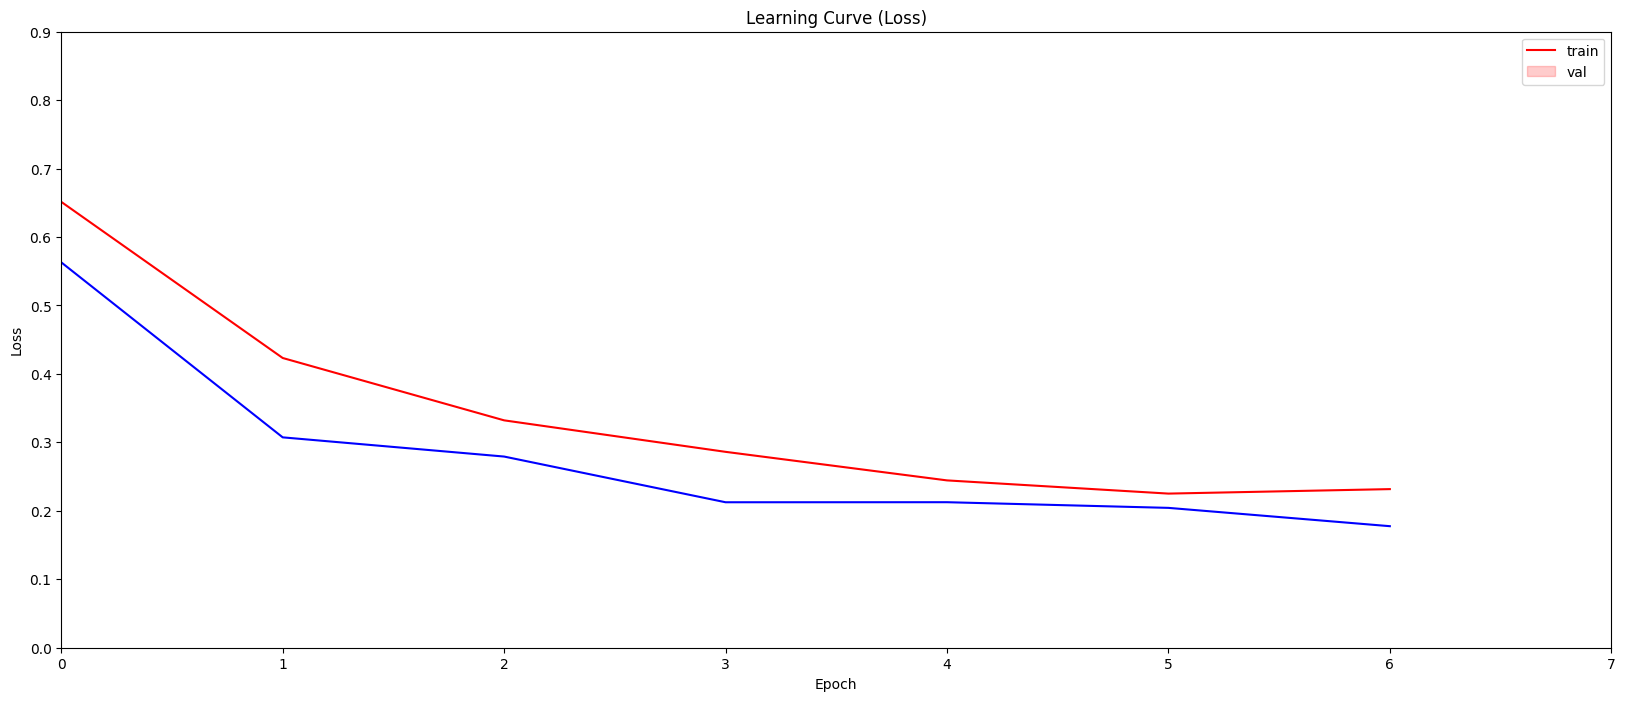

In [28]:
plt.figure(figsize=(20,8))
sns.lineplot(x = history2.epoch, y = history2.history['loss'], color = 'red')
sns.lineplot(x = history2.epoch, y = history2.history['val_loss'], color = 'blue')
plt.title('Learning Curve (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.ylim(0, 0.9)
plt.xlim(0, 7)
plt.legend(['train', 'val'], loc='best')


**ACCURACY VS VAL_ACCURACY**

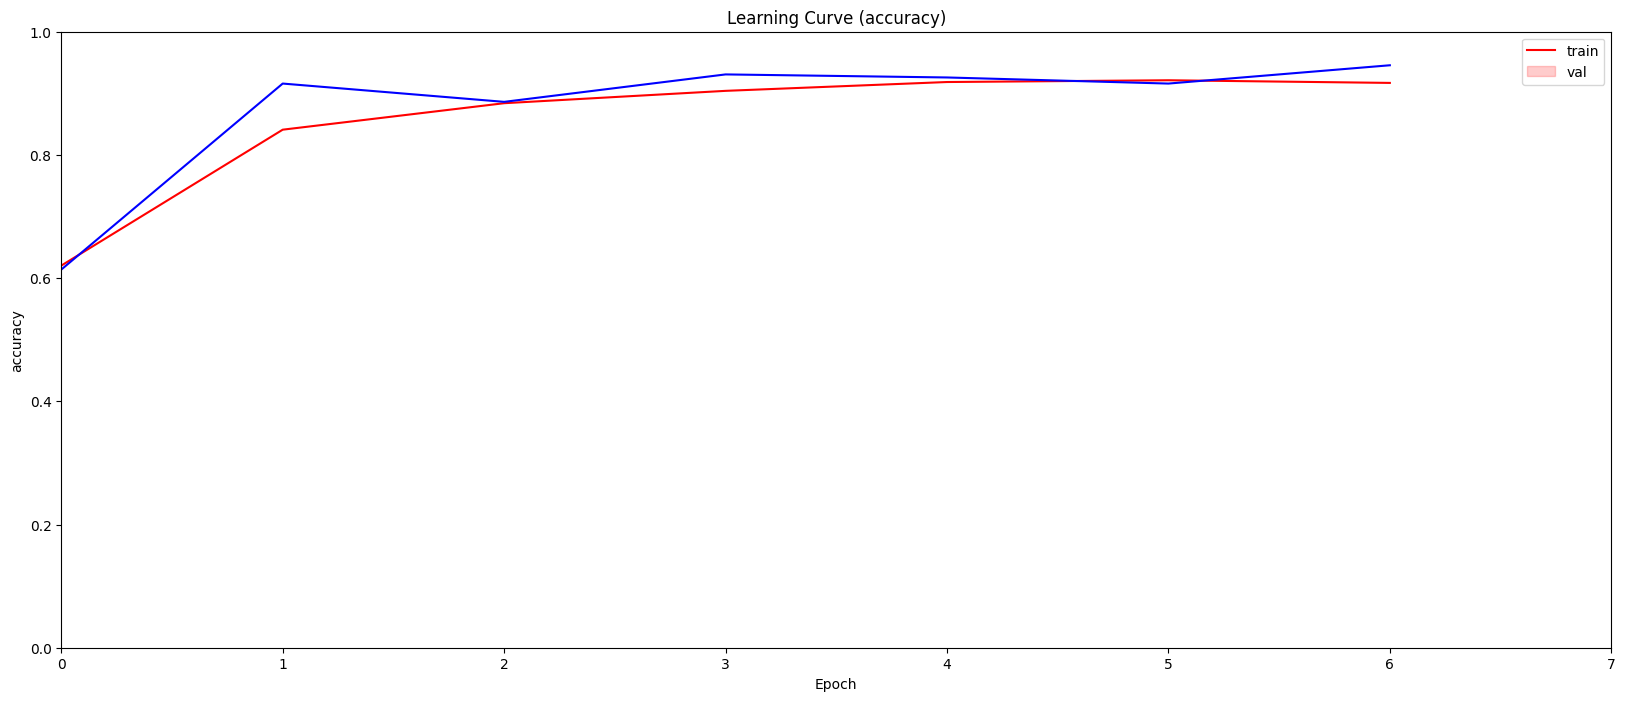

In [31]:
plt.figure(figsize=(20,8))
sns.lineplot(x = history2.epoch, y = history2.history['accuracy'], color = 'red')
sns.lineplot(x = history2.epoch, y = history2.history['val_accuracy'], color = 'blue')

plt.title('Learning Curve (accuracy)')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.xlim(0, 7)
plt.legend(['train', 'val'], loc='best')


4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step


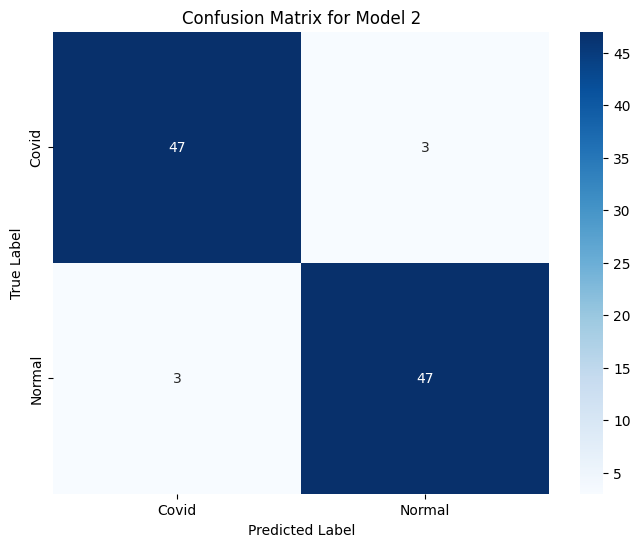

In [32]:


model2.load_weights('best_model2.keras')

test_labels = test_generator.classes

predictions = model2.predict(test_generator)

y_pred = np.round(predictions).flatten()

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix for Model 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [39]:
score2 = model2.evaluate(test_generator, verbose = 0)
print('Test loss:', round(score2[0],2))
print('Test accuracy:', round(score2[1],2))

Test loss: 0.21
Test accuracy: 0.94


**When both training accuracy and validation accuracy are high and close to each other, and the validation loss is low, the model is considered to be at its optimal performance point.**

# Model 3


In [40]:

model3_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="CNN3.weights.h5",
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

early_stopping3 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

reduce_lr3 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=3, min_lr=0.001)

In [41]:
img_size = 224

model3 = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
history3 = model3.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    callbacks=[model3_checkpoint_callback, early_stopping3, reduce_lr3]
)


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.5139 - loss: 0.7479 - val_accuracy: 0.9257 - val_loss: 0.2456 - learning_rate: 0.0010
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.8378 - loss: 0.4042 - val_accuracy: 0.9257 - val_loss: 0.2730 - learning_rate: 0.0010
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.8636 - loss: 0.3277 - val_accuracy: 0.9356 - val_loss: 0.2032 - learning_rate: 0.0010
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.9017 - loss: 0.2438 - val_accuracy: 0.9505 - val_loss: 0.1807 - learning_rate: 0.0010
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.8987 - loss: 0.2832 - val_accuracy: 0.9505 - val_loss: 0.1744 - learning_rate: 0.0010
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.9216 - loss: 0.2104 - val_accuracy: 0.9356 - val_loss: 0.2040 - learning_rate: 0.0010
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.8843 - loss: 0.2857 - val_accuracy: 

<function matplotlib.pyplot.show(close=None, block=None)>

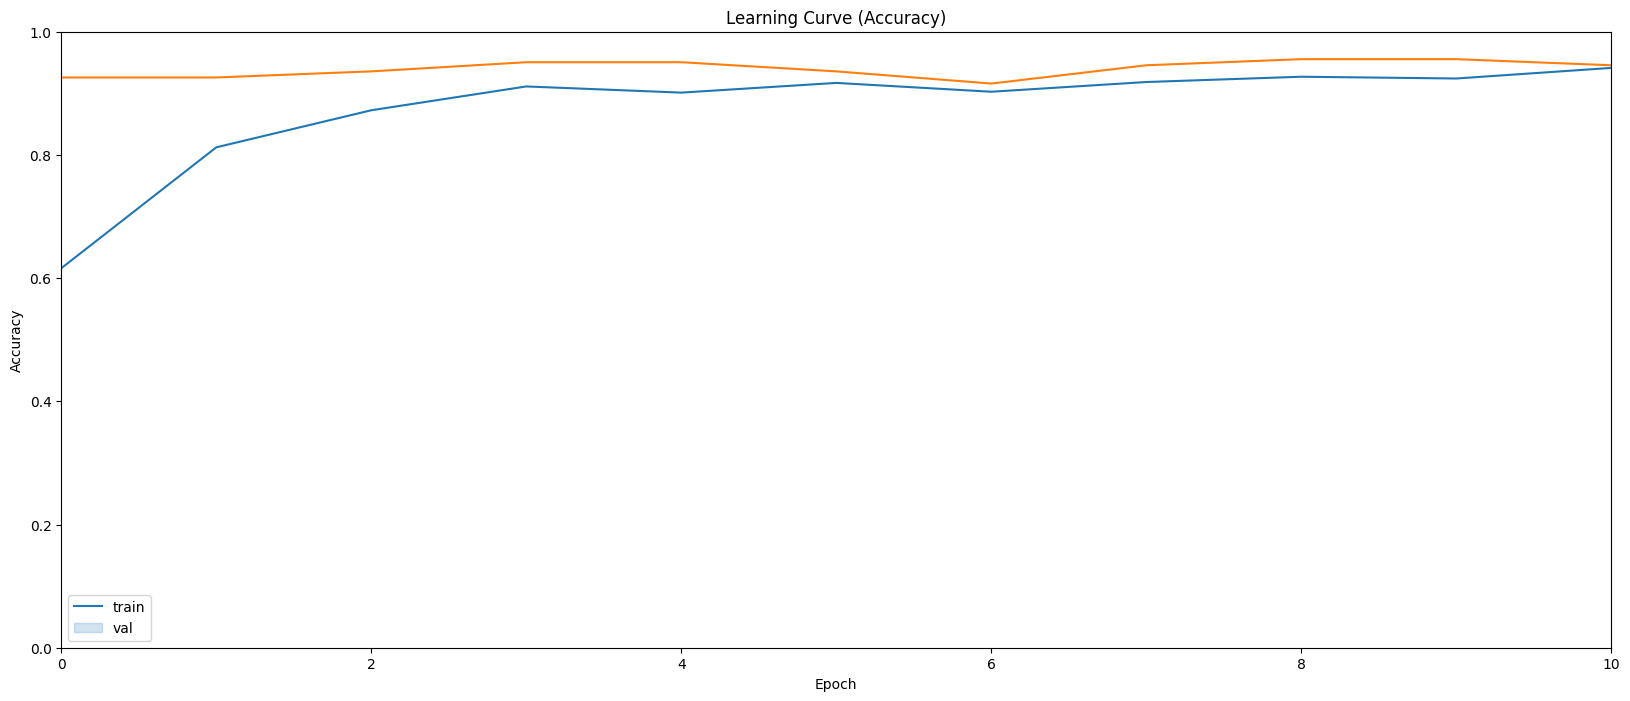

In [47]:
plt.figure(figsize=(20,8))
sns.lineplot(x = history3.epoch, y = history3.history['accuracy'])
sns.lineplot(x = history3.epoch, y = history3.history['val_accuracy'])
plt.title('Learning Curve (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.xlim(0, 10)
plt.legend(['train', 'val'], loc='best')
plt.show

**The training and validation accuracy curves are both high and closely aligned, indicating stable learning and good generalization without clear overfitting.**

<function matplotlib.pyplot.show(close=None, block=None)>

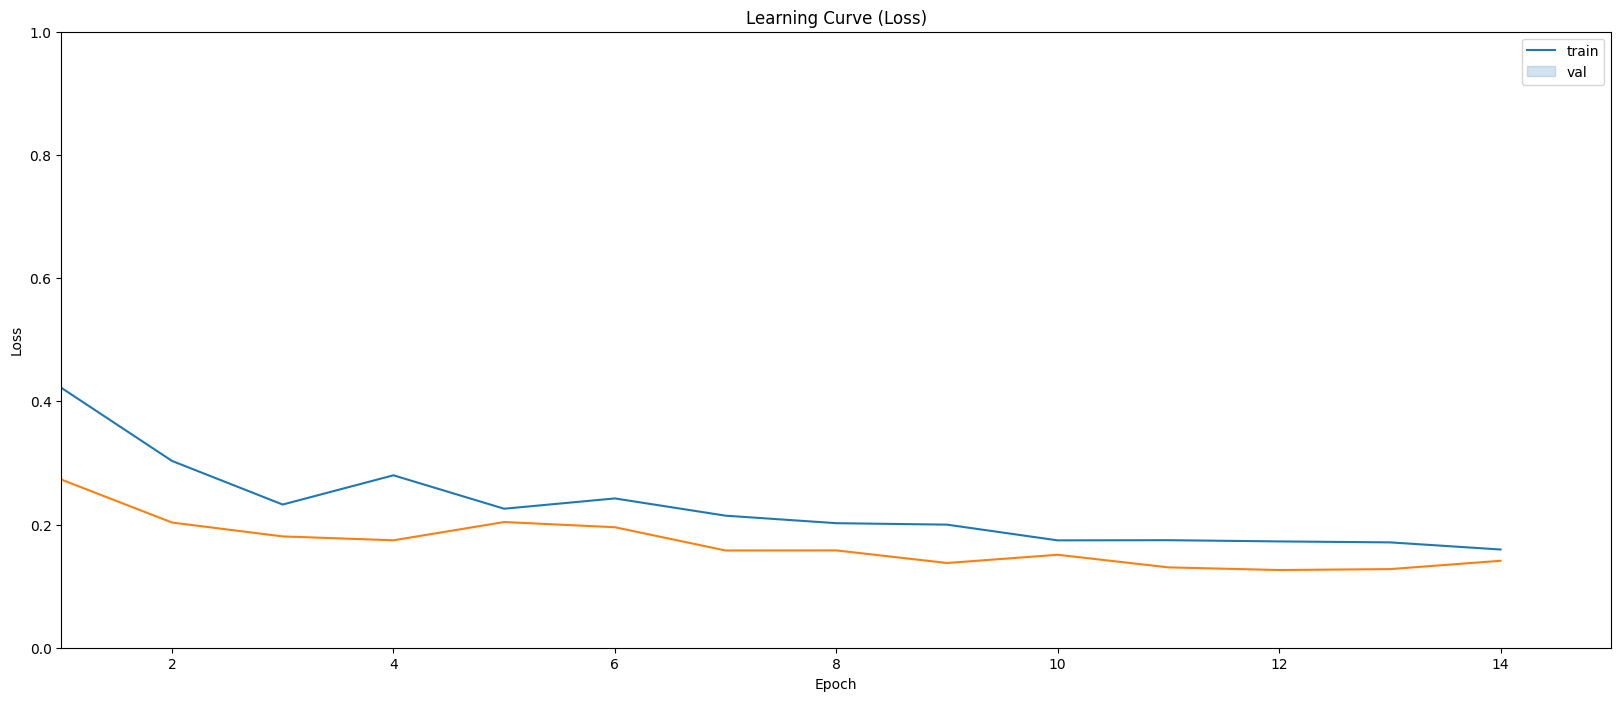

In [48]:
plt.figure(figsize=(20,8))
sns.lineplot(x = history3.epoch, y = history3.history['loss'])
sns.lineplot(x = history3.epoch, y = history3.history['val_loss'])
plt.title('Learning Curve (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.xlim(1,15)
plt.legend(['train', 'val'], loc='best')
plt.show

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 618ms/step


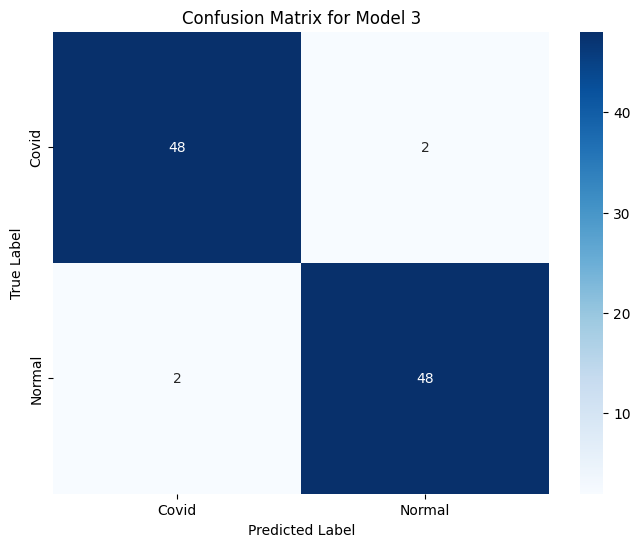

In [49]:
model3.load_weights('CNN3.weights.h5')

test_labels = test_generator.classes

predictions = model3.predict(test_generator)

y_pred = np.round(predictions).flatten()

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix for Model 3')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [50]:
best_epoch = history3.history['val_loss'].index(
    min(history3.history['val_loss'])
) + 1

print("Best epoch:", best_epoch)
print("Best val_loss:", round(min(history3.history['val_loss']),3))
print("Best val_accuracy:", round(max(history3.history['val_accuracy']),2))
print("Best train_loss:", round(min(history3.history['loss']),3))
print("Best train_accuracy:", round(max(history3.history['accuracy']),2))


Best epoch: 13
Best val_loss: 0.126
Best val_accuracy: 0.96
Best train_loss: 0.159
Best train_accuracy: 0.94


**At epoch 14, the model achieved its best performance with high and closely aligned training and validation accuracy, along with low loss values, indicating good generalization.**

In [52]:
score3 = model3.evaluate(test_generator, verbose = 0)
print('Test loss:', round(score3[0],2))
print('Test accuracy:', round(score3[1],2))

Test loss: 0.13
Test accuracy: 0.96


# Model 4 , with apply masks


In [53]:
import os


split_data_masked_dir = './split_data_masked'


os.makedirs(split_data_masked_dir, exist_ok=True)


splits = ['train', 'validation', 'test']
classes = ['Covid', 'Normal']

for split in splits:
    for cls in classes:
        path = os.path.join(split_data_masked_dir, split, cls)
        os.makedirs(path, exist_ok=True)
        print(f"Created directory: {path}")

Created directory: ./split_data_masked/train/Covid
Created directory: ./split_data_masked/train/Normal
Created directory: ./split_data_masked/validation/Covid
Created directory: ./split_data_masked/validation/Normal
Created directory: ./split_data_masked/test/Covid
Created directory: ./split_data_masked/test/Normal


In [54]:
import os
import numpy as np
from PIL import Image

covid_img_dir  = '/content/drive/MyDrive/covid_dataset/New_covid_vs_normal/Covid_New/Covid'
covid_mask_dir = '/content/drive/MyDrive/covid_dataset/New_covid_vs_normal/Covid_New/Mask'
normal_img_dir  = '/content/drive/MyDrive/covid_dataset/New_covid_vs_normal/Normal_New/Normal'
normal_mask_dir = '/content/drive/MyDrive/covid_dataset/New_covid_vs_normal/Normal_New/Normal_mask'

split_data_dir = './split_data'
split_data_masked_dir = './split_data_masked'

splits = ['train', 'validation', 'test']
classes = ['Covid', 'Normal']

TARGET_SIZE = (224, 224)

def get_original_mask_path(split_img_path):

    filename = os.path.basename(split_img_path)
    cls = os.path.basename(os.path.dirname(split_img_path))

    if cls == 'Covid':
        return os.path.join(covid_mask_dir, filename)
    elif cls == 'Normal':
        return os.path.join(normal_mask_dir, filename)
    else:
        raise ValueError(f"Unknown class: {cls}")

def apply_mask_to_image(image_path, mask_path):

    try:

        img_pil = Image.open(image_path).convert('L').resize(TARGET_SIZE)

        mask_pil = Image.open(mask_path).convert('L').resize(TARGET_SIZE)

        img_np = np.array(img_pil)
        mask_np = np.array(mask_pil)


        mask_normalized = mask_np / 255.0


        masked_img_np = img_np * mask_normalized

        return Image.fromarray(masked_img_np.astype(np.uint8))
    except Exception as e:
        print(f"Error processing {image_path} with mask {mask_path}: {e}")
        return None


print("Starting masking process...")
for split in splits:
    for cls in classes:
        source_dir = os.path.join(split_data_dir, split, cls)
        destination_dir = os.path.join(split_data_masked_dir, split, cls)


        image_files = [f for f in os.listdir(source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for image_filename in image_files:
            original_image_path = os.path.join(source_dir, image_filename)
            original_mask_path = get_original_mask_path(original_image_path)

            masked_image_pil = apply_mask_to_image(original_image_path, original_mask_path)

            if masked_image_pil is not None:
                save_path = os.path.join(destination_dir, image_filename)
                masked_image_pil.save(save_path)

print("Masking process complete. Masked images saved to ./split_data_masked.")

Starting masking process...
Masking process complete. Masked images saved to ./split_data_masked.


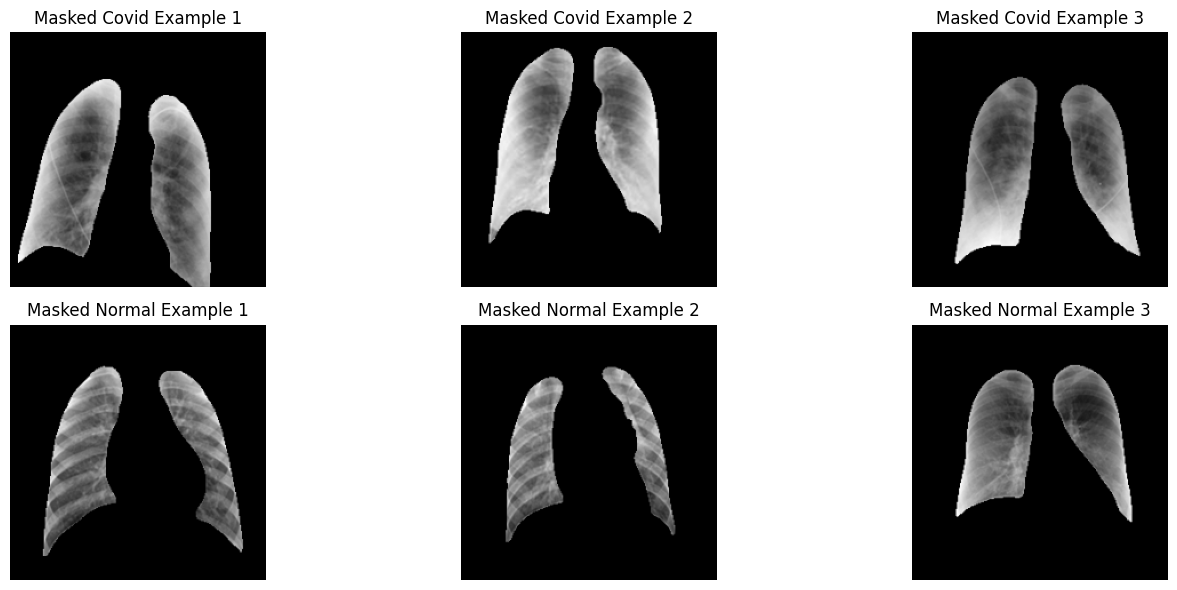

In [55]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image


num_examples_to_show = 3

plt.figure(figsize=(15, 6))


covid_masked_dir = os.path.join(split_data_masked_dir, 'train', 'Covid')
covid_masked_files = os.listdir(covid_masked_dir)
random.shuffle(covid_masked_files)
covid_example_paths = [os.path.join(covid_masked_dir, f) for f in covid_masked_files[:num_examples_to_show]]

for i, img_path in enumerate(covid_example_paths):
    plt.subplot(2, num_examples_to_show, i + 1)
    img = Image.open(img_path)
    plt.imshow(img, cmap='gray')
    plt.title(f'Masked Covid Example {i+1}')
    plt.axis('off')


normal_masked_dir = os.path.join(split_data_masked_dir, 'train', 'Normal')
normal_masked_files = os.listdir(normal_masked_dir)
random.shuffle(normal_masked_files)
normal_example_paths = [os.path.join(normal_masked_dir, f) for f in normal_masked_files[:num_examples_to_show]]

for i, img_path in enumerate(normal_example_paths):
    plt.subplot(2, num_examples_to_show, num_examples_to_show + i + 1)
    img = Image.open(img_path)
    plt.imshow(img, cmap='gray')
    plt.title(f'Masked Normal Example {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [56]:
train_datagen_masked = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2 ,
    horizontal_flip=False
)

validation_datagen_masked = ImageDataGenerator(rescale=1./255)

test_datagen_masked = ImageDataGenerator(rescale=1./255)

train_generator_masked = train_datagen_masked.flow_from_directory(
    './split_data_masked/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

valid_generator_masked = validation_datagen_masked.flow_from_directory(
    './split_data_masked/validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    color_mode='grayscale'
)

test_generator_masked = test_datagen_masked.flow_from_directory(
    './split_data_masked/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    color_mode='grayscale'
)


Found 698 images belonging to 2 classes.
Found 202 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


## Define and Compile New CNN Model (Model 4)



In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

img_size = 224

model4 = keras.Sequential([
    keras.Input(shape=(img_size, img_size, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model4.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train Model 4 with Masked Images



In [58]:
model4_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="CNN4.weights.h5",
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

early_stopping4 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

reduce_lr4 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=3, min_lr=0.001)


history4 = model4.fit(
    train_generator_masked,
    epochs=15,
    validation_data=valid_generator_masked,
    callbacks=[model4_checkpoint_callback, early_stopping4, reduce_lr4]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.6457 - loss: 0.6579 - val_accuracy: 0.8812 - val_loss: 0.4008 - learning_rate: 0.0010
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8399 - loss: 0.4092 - val_accuracy: 0.9208 - val_loss: 0.2477 - learning_rate: 0.0010
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.8972 - loss: 0.2818 - val_accuracy: 0.9406 - val_loss: 0.2251 - learning_rate: 0.0010
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.9145 - loss: 0.2356 - val_accuracy: 0.9356 - val_loss: 0.2104 - learning_rate: 0.0010
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.9295 - loss: 0.1954 - val_accuracy: 0.9406 - val_loss: 0.2153 - learning_rate: 0.0010
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9441 - loss: 0.1696 - val_accuracy: 0.9307 - val_loss: 0.2196 - learning_rate: 0.0010
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9347 - loss: 0.1820 - val_accuracy: 

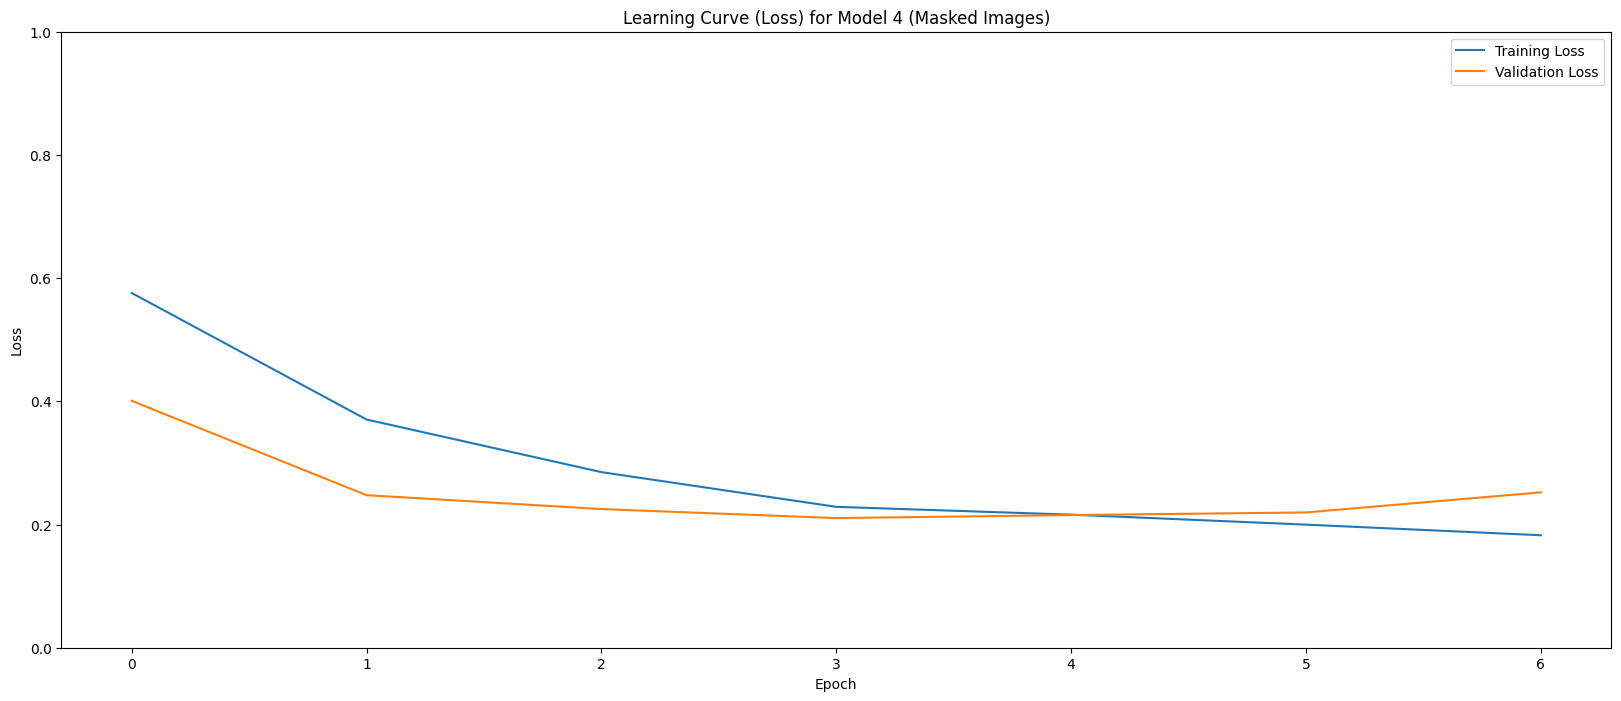

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting training and validation loss for Model 4
plt.figure(figsize=(20,8))
sns.lineplot(x = history4.epoch, y = history4.history['loss'], label='Training Loss')
sns.lineplot(x = history4.epoch, y = history4.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (Loss) for Model 4 (Masked Images)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.legend(loc='best')
plt.show()



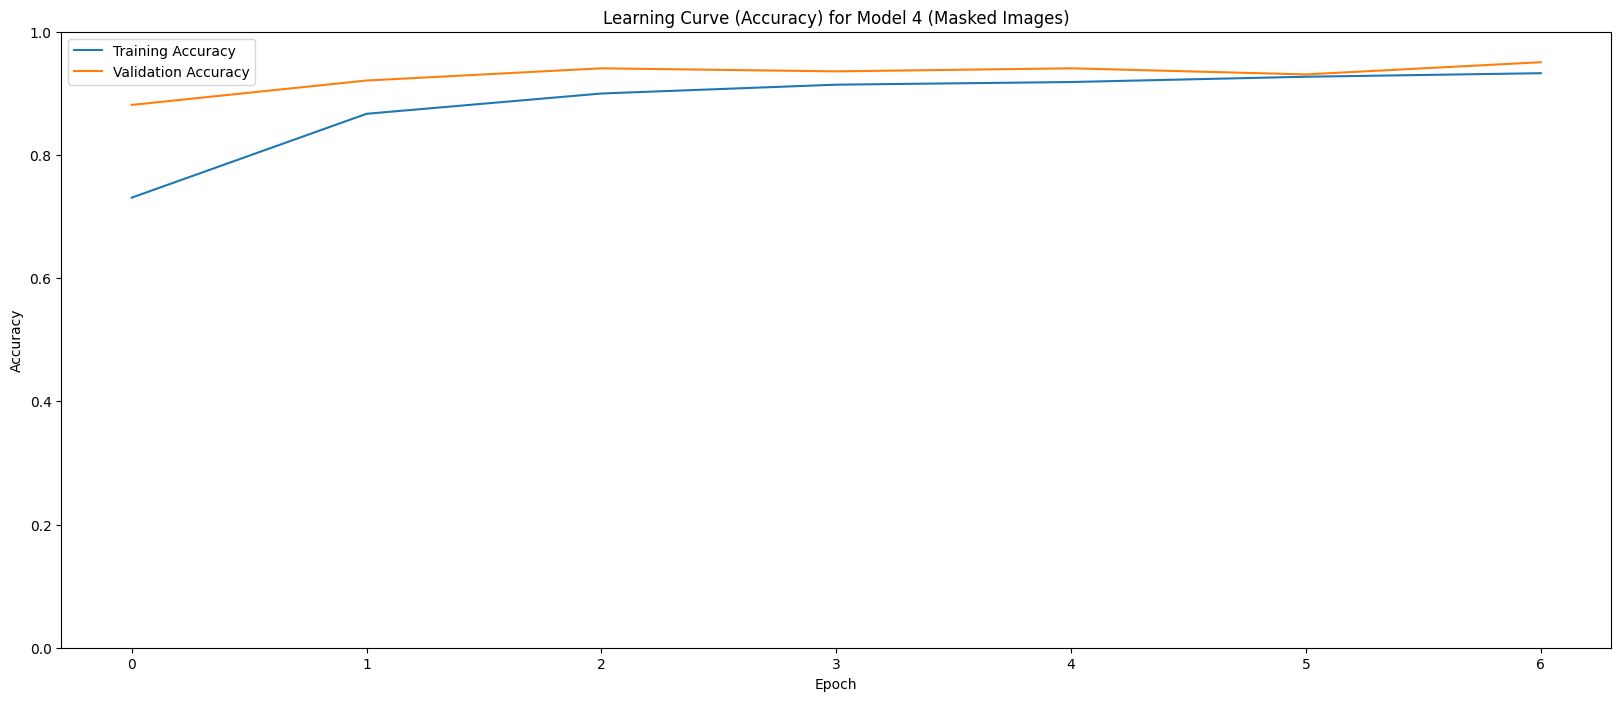

In [60]:
# Plotting training and validation accuracy for Model 4
plt.figure(figsize=(20,8))
sns.lineplot(x = history4.epoch, y = history4.history['accuracy'], label='Training Accuracy')
sns.lineplot(x = history4.epoch, y = history4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Curve (Accuracy) for Model 4 (Masked Images)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.legend(loc='best')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step


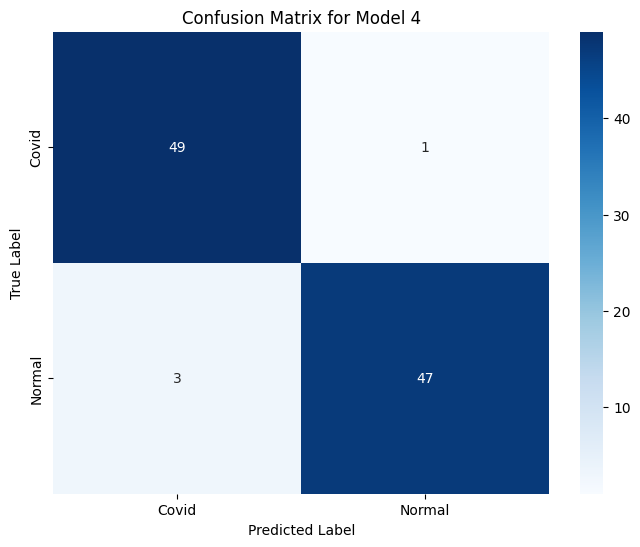

In [61]:

model4.load_weights('CNN4.weights.h5')

test_labels = test_generator_masked.classes

predictions = model4.predict(test_generator_masked)

y_pred = np.round(predictions).flatten()

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator_masked.class_indices.keys(),
            yticklabels=test_generator_masked.class_indices.keys())
plt.title('Confusion Matrix for Model 4')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [66]:
score4 = model4.evaluate(test_generator_masked, verbose = 0)
print('Test loss:', round(score4[0],2))
print('Test accuracy:', round(score4[1],2))

Test loss: 0.18
Test accuracy: 0.96


In [62]:
best_epoch4 = history4.history['val_loss'].index(
    min(history4.history['val_loss'])
) + 1

print("Best epoch for Model 4:", best_epoch4)
print("Best val_loss for Model 4:", round(min(history4.history['val_loss']),3))
print("Best val_accuracy for Model 4:", round(max(history4.history['val_accuracy']),2))
print("Best train_loss for Model 4:", round(min(history4.history['loss']),3))
print("Best train_accuracy for Model 4:", round(max(history4.history['accuracy']),2))

Best epoch for Model 4: 4
Best val_loss for Model 4: 0.21
Best val_accuracy for Model 4: 0.95
Best train_loss for Model 4: 0.183
Best train_accuracy for Model 4: 0.93


## Compare Model 3 and Model 4 Metrics


To compare the models, I will print the best validation loss and accuracy for both Model 3 and Model 4 using the pre-calculated values and their corresponding best epochs.



In [63]:
print("--- Model 3 Metrics ---")
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Loss: {round(min(history3.history['val_loss']),3)}")
print(f"Best Validation Accuracy: {round(max(history3.history['val_accuracy']),2)}")

print("\n--- Model 4 (Masked Images) Metrics ---")
print(f"Best Epoch: {best_epoch4}")
print(f"Best Validation Loss: {round(min(history4.history['val_loss']),3)}")
print(f"Best Validation Accuracy: {round(max(history4.history['val_accuracy']),2)}")

--- Model 3 Metrics ---
Best Epoch: 13
Best Validation Loss: 0.126
Best Validation Accuracy: 0.96

--- Model 4 (Masked Images) Metrics ---
Best Epoch: 4
Best Validation Loss: 0.21
Best Validation Accuracy: 0.95


## Model 4 or Model 3 ?

###
Yes, Model 3 performs better than Model 4.

### Data Analysis Key Findings
*   Model 3 (trained on raw images) achieved a best validation loss of 0.124 and a best validation accuracy of 0.96.
*   Model 4 (trained on masked images) achieved a best validation loss of 0.210 and a best validation accuracy of 0.95.
*   Both models reached their best performance at Epoch 5.
*   Model 3 demonstrated slightly superior performance with a lower validation loss and higher validation accuracy compared to Model 4.

### Insights or Next Steps
*   The masking process for Model 4 might have inadvertently removed crucial features or important contextual information present in the raw images, leading to slightly reduced performance compared to Model 3.
*   Further investigation into the masking strategy could be beneficial, potentially by refining the masks or exploring different mask generation techniques to ensure essential features are retained.


# Transfer Learning


In [67]:
img_sizee = 224

base_model = tf.keras.applications.ResNet152V2(
    weights='imagenet',
    input_shape=(img_sizee, img_sizee, 3),
    include_top=False)

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [68]:
base_model.trainable = False
def get_pretrained():


    inputs = layers.Input(shape=(img_sizee, img_sizee, 3))

    x = base_model(inputs)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.1)(x)


    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=[inputs], outputs=output)

    return model

In [69]:
keras.backend.clear_session()

model_pretrained = get_pretrained()
model_pretrained.compile(loss='binary_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=5e-5), metrics=['binary_accuracy'])

model_pretrained.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,594,049 (223.52 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

In [70]:
model_pretrained_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="ResNet152V2.weights.h5",
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

early_stopping_tr = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)
reduce_lr_tr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=2, min_lr=0.001)

history = model_pretrained.fit(
    train_generator,
    epochs=6,
    validation_data=valid_generator,
    callbacks=[model_pretrained_checkpoint_callback, early_stopping_tr, reduce_lr_tr])

Epoch 1/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - binary_accuracy: 0.5842 - loss: 0.7438 

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


22/22 ━━━━━━━━━━━━━━━━━━━━ 414s 18s/step - binary_accuracy: 0.5876 - loss: 0.7381 - val_binary_accuracy: 0.8663 - val_loss: 0.3993 - learning_rate: 5.0000e-05
Epoch 2/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 443s 20s/step - binary_accuracy: 0.8550 - loss: 0.3768 - val_binary_accuracy: 0.9406 - val_loss: 0.2585 - learning_rate: 5.0000e-05
Epoch 3/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - binary_accuracy: 0.9379 - loss: 0.2610 

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


22/22 ━━━━━━━━━━━━━━━━━━━━ 390s 18s/step - binary_accuracy: 0.9378 - loss: 0.2605 - val_binary_accuracy: 0.9406 - val_loss: 0.2094 - learning_rate: 5.0000e-05
Epoch 4/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 385s 18s/step - binary_accuracy: 0.9491 - loss: 0.2160 - val_binary_accuracy: 0.9455 - val_loss: 0.1856 - learning_rate: 5.0000e-05
Epoch 5/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 386s 18s/step - binary_accuracy: 0.9342 - loss: 0.1941 - val_binary_accuracy: 0.9406 - val_loss: 0.1751 - learning_rate: 5.0000e-05
Epoch 6/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 384s 18s/step - binary_accuracy: 0.9122 - loss: 0.2092 - val_binary_accuracy: 0.9455 - val_loss: 0.1657 - learning_rate: 5.0000e-05


(0.0, 1.0)

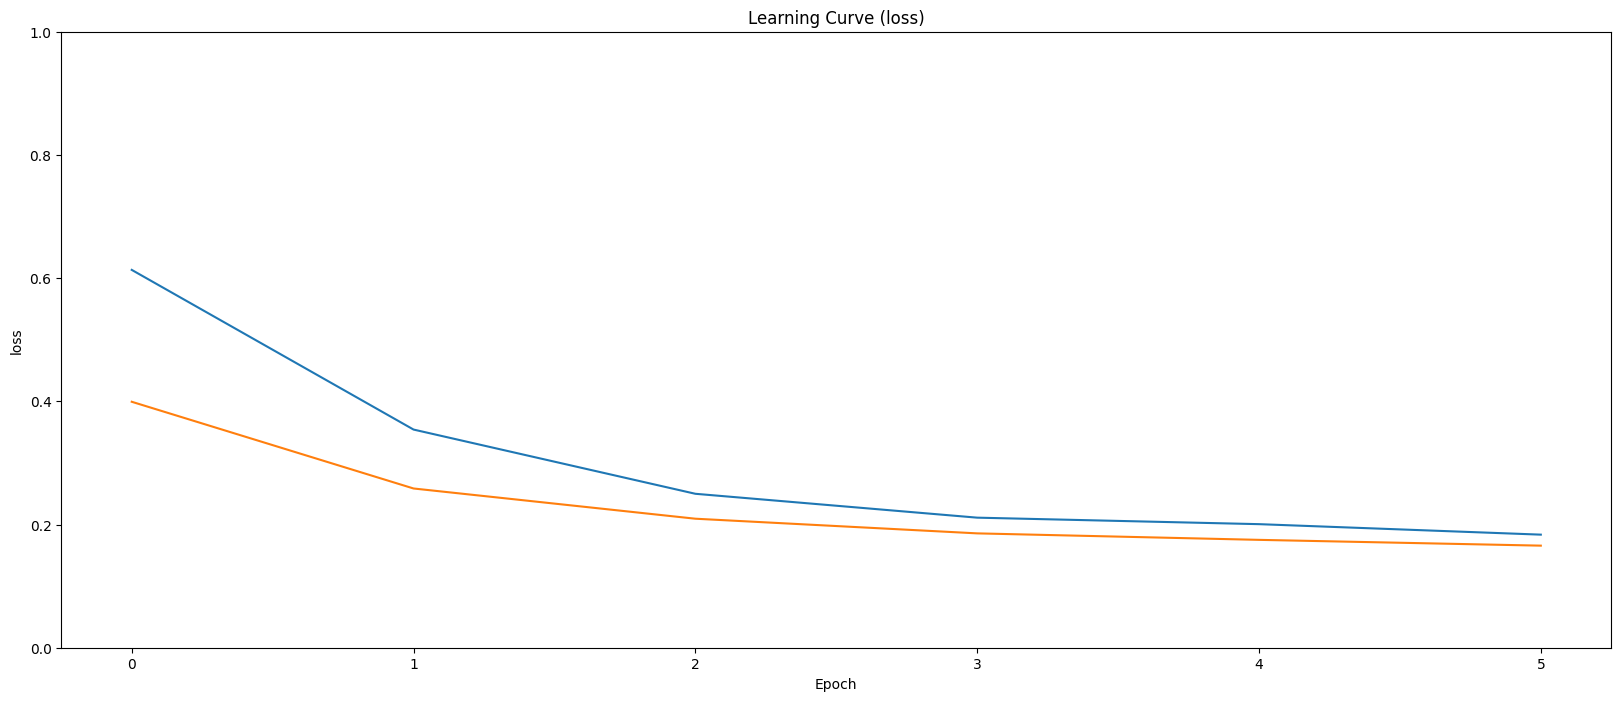

In [71]:
plt.figure(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
plt.title('Learning Curve (loss)')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.ylim(0, 1)

(0.0, 1.0)

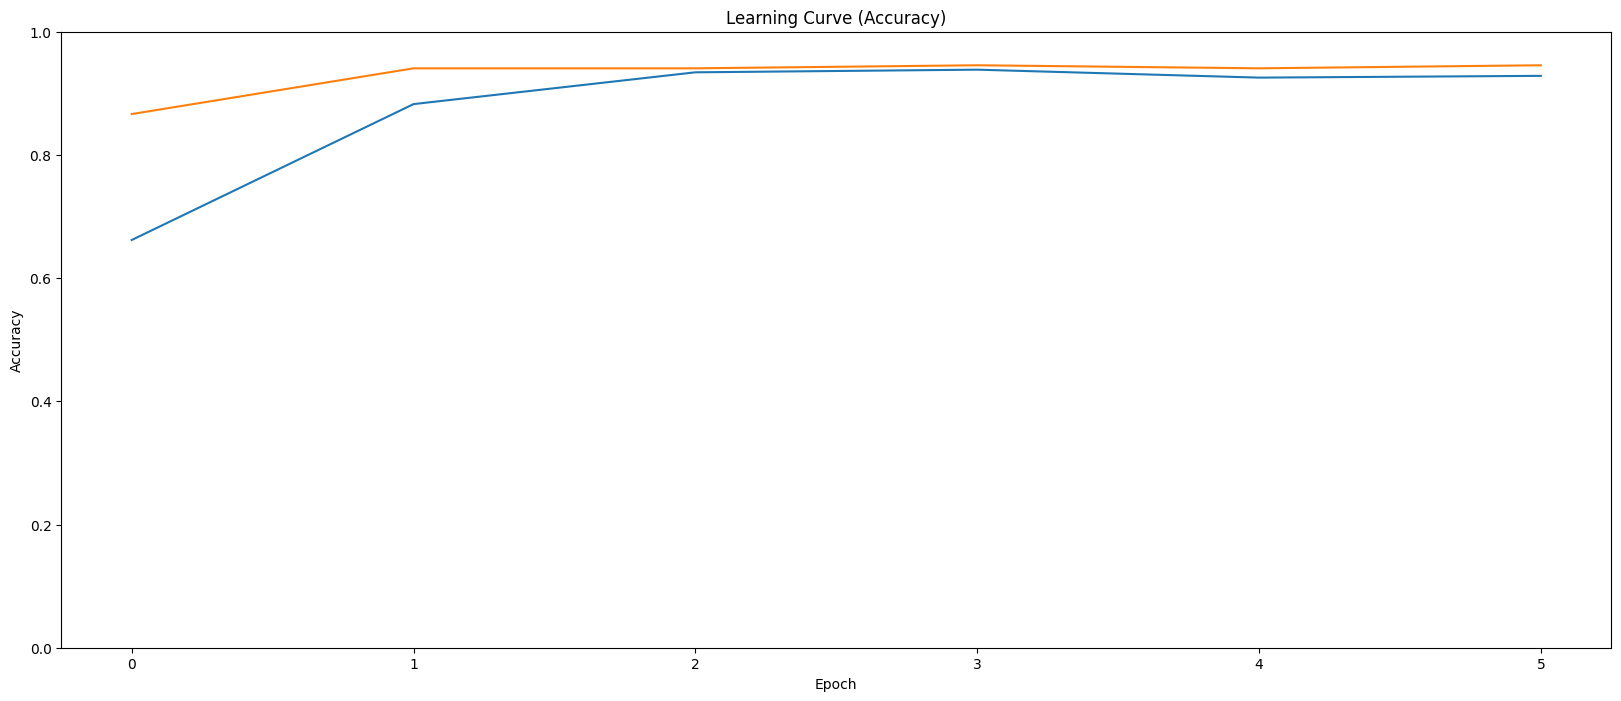

In [72]:
plt.figure(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['binary_accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_binary_accuracy'])
plt.title('Learning Curve (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)

3/4 ━━━━━━━━━━━━━━━━━━━━ 13s 14s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 54s 12s/step


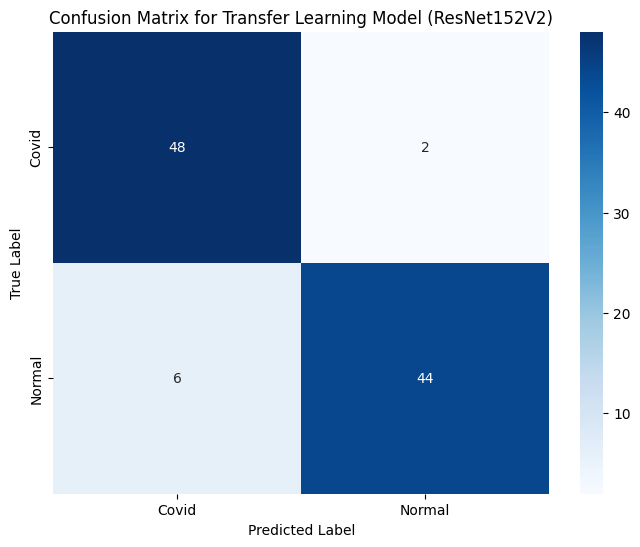

In [73]:

model_pretrained.load_weights('ResNet152V2.weights.h5')

test_labels = test_generator.classes

predictions = model_pretrained.predict(test_generator)

y_pred = np.round(predictions).flatten()

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix for Transfer Learning Model (ResNet152V2)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [75]:
score5 = model_pretrained.evaluate(test_generator, verbose = 0)

print('Test loss:', round(score[0],2))
print('Test accuracy:', round(score[1],2))

Test loss: 0.25
Test accuracy: 0.94
